In [15]:
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv(f'data/income.csv')
df.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


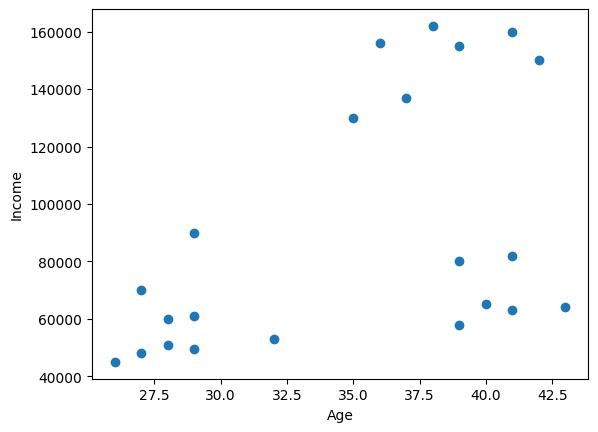

In [17]:
plt.xlabel('Age')
plt.ylabel('Income')
plt.scatter(df.Age, df['Income($)'])

In [18]:
from sklearn.cluster import KMeans

In [ ]:
km = KMeans(n_clusters=3,random_state=0) # random_state for reproducibility

In [20]:
y_predicted = km.fit_predict(df[['Age', 'Income($)']])
y_predicted

array([2, 0, 2, 2, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2],
      dtype=int32)

In [21]:
km.cluster_centers_

array([[3.63333333e+01, 8.40000000e+04],
       [3.82857143e+01, 1.50000000e+05],
       [3.24166667e+01, 5.72916667e+04]])

In [22]:
df['cluster'] = y_predicted
df.head()

,Name,Age,Income($),cluster
0,Rob,27,70000,2
1,Michael,29,90000,0
2,Mohan,29,61000,2
3,Ismail,28,60000,2
4,Kory,42,150000,1


In [23]:
df1 = df[df.cluster == 0]
df2 = df[df.cluster == 1]
df3 = df[df.cluster == 2]

/tmp/ipython-input-1016213518.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


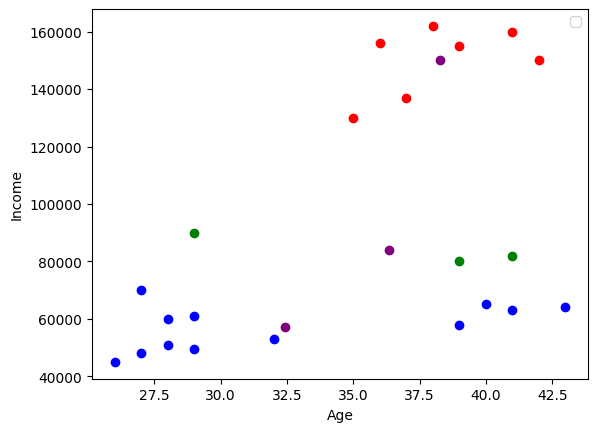

In [24]:
plt.scatter(df1.Age, df1['Income($)'], color = 'Green')
plt.scatter(df2.Age, df2['Income($)'], color = 'Red')
plt.scatter(df3.Age, df3['Income($)'], color = 'Blue')
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], color = 'Purple')
plt.xlabel("Age")
plt.ylabel("Income")
plt.legend()

In [25]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [26]:
scaler.fit(df[['Income($)']])
df['Income($)'] = scaler.transform(df[['Income($)']])

In [27]:
scaler.fit(df[['Age']])
df['Age'] = scaler.transform(df[['Age']])

In [28]:
df.head()

,Name,Age,Income($),cluster
0,Rob,0.058824,0.213675,2
1,Michael,0.176471,0.384615,0
2,Mohan,0.176471,0.136752,2
3,Ismail,0.117647,0.128205,2
4,Kory,0.941176,0.897436,1


In [29]:
km = KMeans(n_clusters=3)

In [30]:
y_predicted = km.fit_predict(df[['Age', 'Income($)']])
y_predicted

array([1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
      dtype=int32)

In [31]:
df['cluster'] = y_predicted
df.head()

,Name,Age,Income($),cluster
0,Rob,0.058824,0.213675,1
1,Michael,0.176471,0.384615,1
2,Mohan,0.176471,0.136752,1
3,Ismail,0.117647,0.128205,1
4,Kory,0.941176,0.897436,2


In [32]:
df1 = df[df.cluster == 0]
df2 = df[df.cluster == 1]
df3 = df[df.cluster == 2]

/tmp/ipython-input-1016213518.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


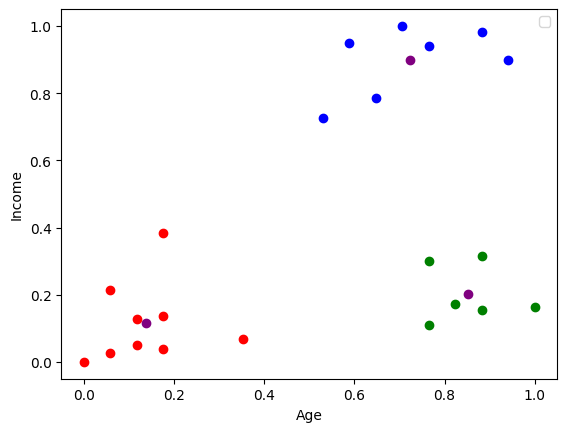

In [33]:
plt.scatter(df1.Age, df1['Income($)'], color = 'Green')
plt.scatter(df2.Age, df2['Income($)'], color = 'Red')
plt.scatter(df3.Age, df3['Income($)'], color = 'Blue')
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], color = 'Purple')
plt.xlabel("Age")
plt.ylabel("Income")
plt.legend()

In [34]:
wcss = []
k_rng = range(1, 10)
for k in k_rng:
  km = KMeans(n_clusters=k)
  km.fit(df[['Age', 'Income($)']])
  wcss.append(km.inertia_)


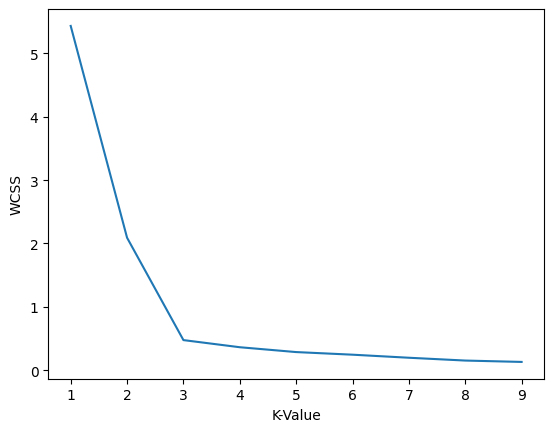

In [35]:
plt.xlabel('K-Value')
plt.ylabel('WCSS')
plt.plot(k_rng, wcss)